In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits
from sklearn.metrics import confusion_matrix

In [2]:
save_data=False

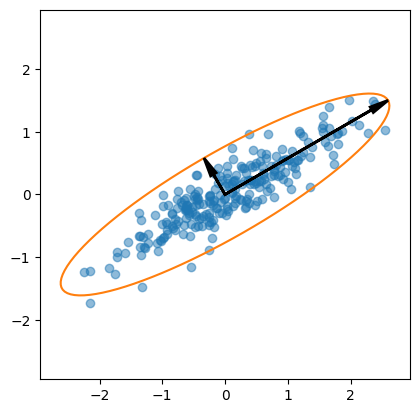

In [3]:
def generate_Gaussian(mu, C, Ndata):
    dim=mu.shape[0]
    xi = np.random.normal(0,1, (dim, Ndata))
    lam,ev =np.linalg.eigh(C)
    sqrt_C = ev@np.diag(np.sqrt(lam))@ev.T
    return sqrt_C@xi + mu

def twoD_Gaussian(mu, lam, phi, Ndata):
    V = np.array([[np.cos(phi), -np.sin(phi)], [np.sin(phi), np.cos(phi)]])
    D = np.diag(np.sqrt(lam))
    sqrt_C = V@D@V.T
    xi = np.random.normal(0,1, (2, Ndata))
    Dinv = np.diag(1/np.array(lam))
    return sqrt_C@xi + mu, V, V@Dinv@V.T


Ndata=250
phi=np.pi/6
np.random.seed(120)
lamx = [1,0.05]
data, ev,Cinv = twoD_Gaussian(0, lamx, phi=phi, Ndata=Ndata)
distance = np.sqrt(np.diagonal(data.T@Cinv@data))

d = np.max(data)+0.4
plt.xlim(-d,d)
plt.ylim(-d,d)
plt.axis('scaled')

Npoints=100
basis = np.array([ (np.cos(2*np.pi*t),np.sin(2*np.pi*t)) for t in np.linspace(0,1,Npoints)]).T
plt.plot(*((3*np.sqrt(lamx)*ev)@basis), color='tab:orange')
colr = distance>3
plt.scatter(*data, c='tab:blue', alpha=0.5)
for i in range(2):
    plt.arrow(0,0, *(3*np.sqrt(lamx[i])*ev[:,i]), head_width=0.1, head_length=0.3, lw=2,
         fc='black', ec='black', clip_on=False, zorder=4, length_includes_head=True)
if save_data: plt.savefig('Pics/eigendirections.pdf', transparent=True)
plt.show()

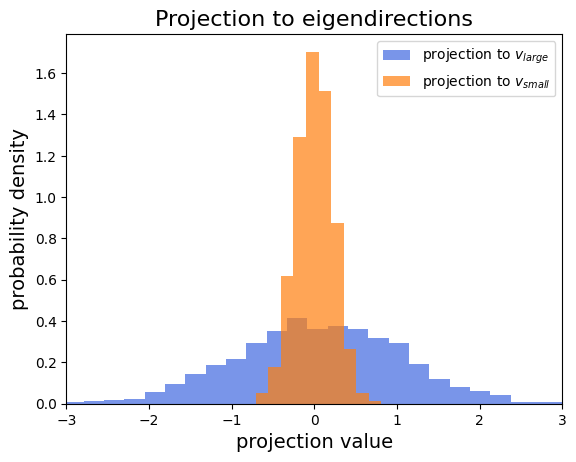

In [4]:
Ndata=1500
phi=np.pi/6
np.random.seed(120)
lamx = [1,0.05]
data, ev,Cinv = twoD_Gaussian(0, lamx, phi=phi, Ndata=Ndata)
U = ev.T@data
plt.hist(U[0], bins=30, density=True, color='royalblue', alpha=0.7, label=r'projection to $v_{large}$')
plt.hist(U[1], density=True, color='tab:orange', alpha=0.7, label=r'projection to $v_{small}$')
plt.xlim(-3,3)
plt.xlabel('projection value', fontsize=14)
plt.ylabel('probability density', fontsize=14)
plt.legend()
plt.title('Projection to eigendirections', fontsize=16)
if save_data: plt.savefig('Pics/PCA_projection_distribution.pdf', transparent=True)


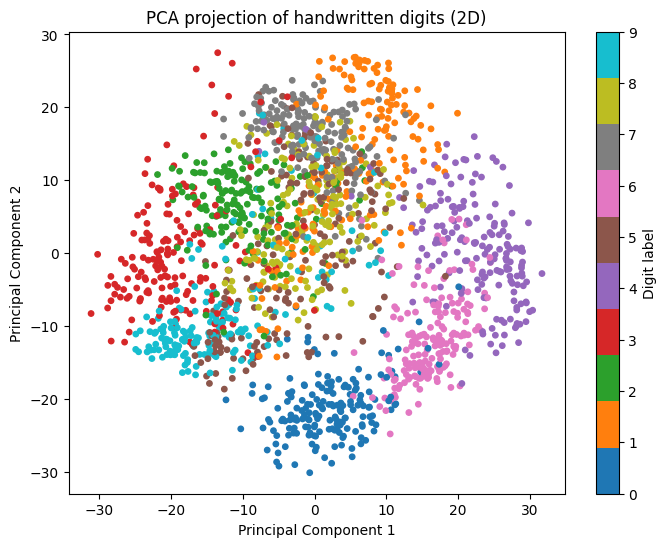

Explained variance by first 2 PCs: 0.28509364823699285


In [5]:
# --- 1. Load dataset (8x8 images of digits 0–9) ---
digits = load_digits()
X = digits.data      # shape (1797, 64)
y = digits.target

# --- 2. Apply PCA to reduce to 2D for visualization ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# --- 3. Plot the projection ---
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='tab10', s=15)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA projection of handwritten digits (2D)")
plt.colorbar(scatter, label="Digit label")
plt.show()

# --- 4. Print explained variance ratio ---
print("Explained variance by first 2 PCs:", pca.explained_variance_ratio_.sum())

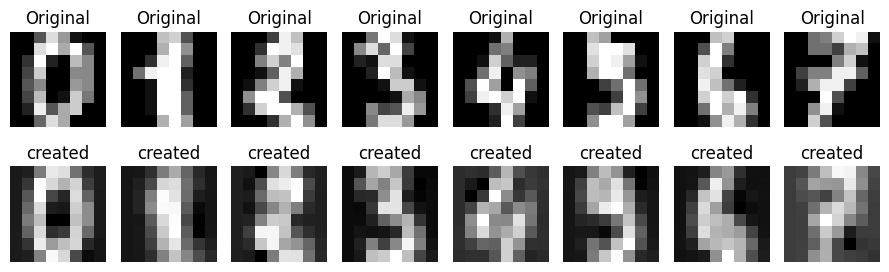

In [6]:
# Reduce to 10 principal components
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X)
X_reconstructed = pca.inverse_transform(X_pca)

# Compare original and reconstructed digits
fig, axes = plt.subplots(2, 8, figsize=(9, 3))
for i in range(8):
    axes[0, i].imshow(X[i].reshape(8,8), cmap='gray')
    axes[0, i].set_title("Original")
    axes[1, i].imshow(X_reconstructed[i].reshape(8,8), cmap='gray')
    axes[1, i].set_title("created")
    for ax in axes[:, i]: ax.axis('off')
plt.tight_layout()
plt.show()


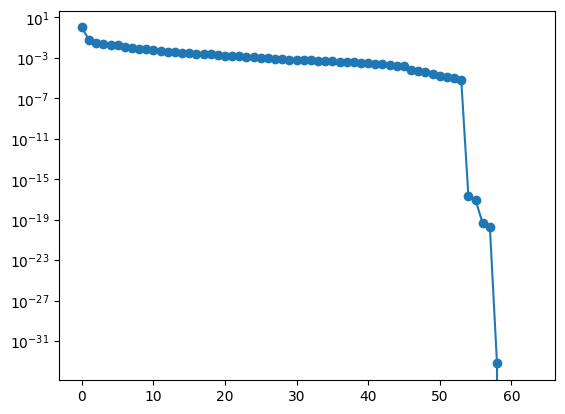

In [7]:
laws = []
Xdigits = [ X[y==yval] for yval in range(10)]
pick = int(0.1*Xdigits[0].shape[1])
pick=10
for yval in range(10):
    lam0, ev0 = np.linalg.eigh(Xdigits[yval].T@Xdigits[yval])
    idx = np.argsort(lam0)[::-1]
    lam_ordered = lam0[idx]
    ev_ordered = ev0[:,idx]
    laws.append(ev_ordered[:,pick:])
laws = np.array(laws)
plt.plot(lam_ordered/np.max(lam_ordered), "o-")
plt.yscale('log')

In [8]:
y_pred = [np.argmin([np.linalg.norm(X[k]@laws[i]) for i in range(10)]) for k in range(len(X))]
confusion_matrix(y,y_pred)

array([[178,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0, 181,   0,   0,   0,   0,   0,   0,   1,   0],
       [  0,   0, 177,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0, 183,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0, 181,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0, 182,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0, 181,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 179,   0,   0],
       [  0,   3,   0,   0,   0,   0,   0,   0, 171,   0],
       [  0,   0,   0,   1,   0,   0,   0,   1,   0, 178]])

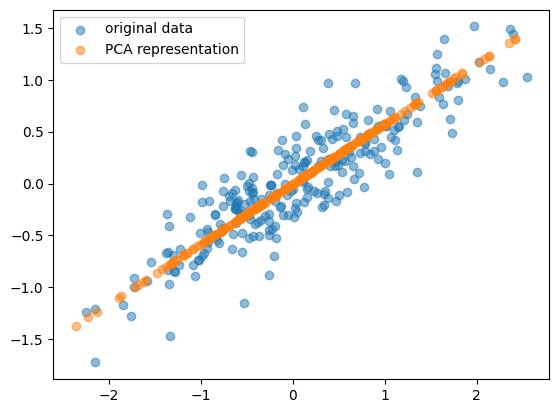

In [9]:
Ndata=250
phi=np.pi/6
np.random.seed(120)
lamx = [1,0.05]
data, ev,Cinv = twoD_Gaussian(0, lamx, phi=phi, Ndata=Ndata)
pca = PCA(n_components=1)
data_pca = pca.fit_transform(data.T)
data_reconstructed = pca.inverse_transform(data_pca)

plt.scatter(*data, c='tab:blue', alpha=0.5, label='original data')
plt.scatter(*data_reconstructed.T, c='tab:orange', alpha=0.5, label='PCA representation')
plt.legend()
if save_data: plt.savefig('Pics/PCA_representation.pdf', transparent=True)
plt.show()


In [10]:
Xdigits[0].shape

(178, 64)

In [11]:
yrange = np.array(sorted(list(set(y))))

In [12]:
yrange

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [13]:
X_pca.shape

(1797, 10)

In [14]:
np.mean(Xdigits[0], axis=0).shape

(64,)

In [15]:
from PCA_law import PCA_law

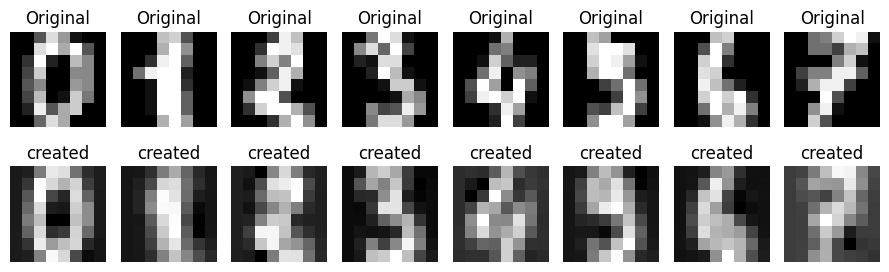

In [16]:
pp = PCA_law(10)
pp.fit(X)
ycomp = pp.compress(X)
Xrec = pp.reconstruct(ycomp)

# Compare original and reconstructed digits
fig, axes = plt.subplots(2, 8, figsize=(9, 3))
for i in range(8):
    axes[0, i].imshow(X[i].reshape(8,8), cmap='gray')
    axes[0, i].set_title("Original")
    axes[1, i].imshow(Xrec[i].reshape(8,8), cmap='gray')
    axes[1, i].set_title("created")
    for ax in axes[:, i]: ax.axis('off')
plt.tight_layout()
plt.show()

In [20]:
from PCA_law import PCA_classifier

In [24]:
pcl = PCA_classifier(n_components= n_components)
pcl.fit(X,y)
y_pred = pcl.predict(X)
confusion_matrix(y,y_pred)

array([[178,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0, 181,   0,   0,   0,   0,   0,   0,   1,   0],
       [  0,   0, 177,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0, 183,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0, 181,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0, 182,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0, 181,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 179,   0,   0],
       [  0,   1,   0,   0,   0,   0,   0,   0, 173,   0],
       [  0,   0,   0,   0,   0,   0,   0,   1,   0, 179]])